In [ ]:
!pip install unifiedbooster

In [3]:
import os
import unifiedbooster as ub
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score


# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the unified clf (example with XGBoost)
clf1 = ub.GBDTClassifier(model_type="xgboost")
# clf2 = ub.GBDTClassifier(model_type='catboost')
clf3 = ub.GBDTClassifier(model_type="lightgbm")
clf4 = ub.GBDTClassifier(model_type="gradientboosting", colsample=0.9)

# Fit the model
clf1.fit(X_train, y_train)
# clf2.fit(X_train, y_train)
clf3.fit(X_train, y_train)
clf4.fit(X_train, y_train)

# Predict on the test set
y_pred1 = clf1.predict(X_test)
# y_pred2 = clf2.predict(X_test)
y_pred3 = clf3.predict(X_test)
y_pred4 = clf4.predict(X_test)

# Evaluate the model
accuracy1 = accuracy_score(y_test, y_pred1)
# accuracy2 = accuracy_score(y_test, y_pred2)
accuracy3 = accuracy_score(y_test, y_pred3)
accuracy4 = accuracy_score(y_test, y_pred4)
print(f"Classification Accuracy xgboost: {accuracy1:.2f}")
# print(f"Classification Accuracy catboost: {accuracy2:.2f}")
print(f"Classification Accuracy lightgbm: {accuracy3:.2f}")
print(f"Classification Accuracy gradientboosting: {accuracy4:.2f}")
print(f"CV xgboost: {cross_val_score(clf1, X_train, y_train)}")
print(f"CV lightgbm: {cross_val_score(clf3, X_train, y_train)}")
print(f"CV gradientboosting: {cross_val_score(clf4, X_train, y_train)}")


Classification Accuracy xgboost: 1.00
Classification Accuracy lightgbm: 1.00
Classification Accuracy gradientboosting: 1.00
CV xgboost: [0.95833333 0.95833333 0.83333333 1.         0.91666667]
CV lightgbm: [0.95833333 0.95833333 0.875      0.95833333 0.95833333]
CV gradientboosting: [0.95833333 0.95833333 0.83333333 1.         0.91666667]


In [5]:
import numpy as np
import os
import unifiedbooster as ub
from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from time import time



load_datasets = [load_iris(), load_breast_cancer(), load_wine()]
dataset_names = ["Iris", "Breast Cancer", "Wine"]

for i, dataset in enumerate(load_datasets):

    print(f"\n ----- Running: {dataset_names[i]} ----- \n")
    X, y = dataset.data, dataset.target

    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Initialize the unified clf (example with XGBoost)
    print("\n ---------- Initialize the unified clf (example with XGBoost)")
    clf1 = ub.GBDTClassifier(model_type="xgboost",
                            level=95,
                            pi_method="tcp")

    # Fit the model
    start = time()
    clf1.fit(X_train, y_train)
    print(f"Time taken: {time() - start} seconds")
    # Predict with the model
    y_pred1 = clf1.predict(X_test)
    print(y_test)
    print(y_pred1.argmax(axis=1))
    # Calculate accuracy
    accuracy = (y_test == y_pred1.argmax(axis=1)).mean()
    print(f"\nAccuracy: {accuracy:.4f}")

    print("\n ---------- Initialize the unified clf (example with LightGBM)")
    clf2 = ub.GBDTClassifier(model_type="lightgbm",
                            level=95,
                            pi_method="icp")
    # Fit the model
    start = time()
    clf2.fit(X_train, y_train)
    print(f"Time taken: {time() - start} seconds")
    # Predict with the model
    y_pred2 = clf2.predict(X_test)
    print(y_pred2)

    # Calculate accuracy
    print(y_test)
    print(y_pred2.argmax(axis=1))
    accuracy = (y_test == y_pred2.argmax(axis=1)).mean()
    print(f"\nAccuracy: {accuracy:.4f}")


 ----- Running: Iris ----- 


 ---------- Initialize the unified clf (example with XGBoost)
Time taken: 7.414817810058594e-05 seconds
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy: 1.0000

 ---------- Initialize the unified clf (example with LightGBM)
Time taken: 0.02053093910217285 seconds
[[False  True  True]
 [ True False False]
 [False False  True]
 [False  True False]
 [False  True  True]
 [ True False False]
 [False  True False]
 [False False  True]
 [False  True False]
 [False  True False]
 [False False  True]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [False  True  True]
 [False False  True]
 [False  True False]
 [False  True False]
 [False False  True]
 [ True False False]
 [False False  True]
 [ True False False]
 [False False  True]
 [False False  True]
 [False False  True]
 [False False  True]
 [False False  True]
 [ True False False]
 [ True Fa


 ----- Running: California Housing ----- 


 ---------- Initialize the unified regr (example with XGBoost)
Time taken: 0.7112090587615967 seconds
Coverage rate: 0.9486


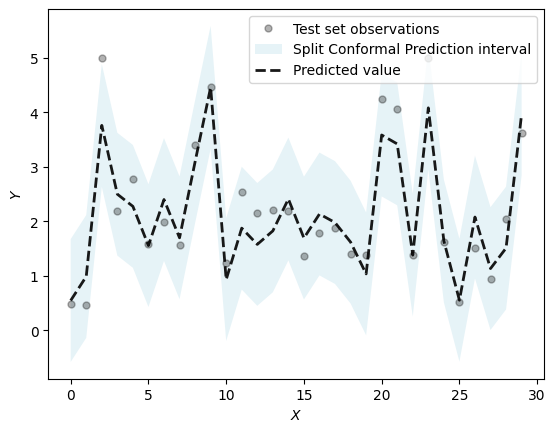


 ---------- Initialize the unified regr (example with LightGBM)
Time taken: 3.389627456665039 seconds
Coverage rate: 0.9998


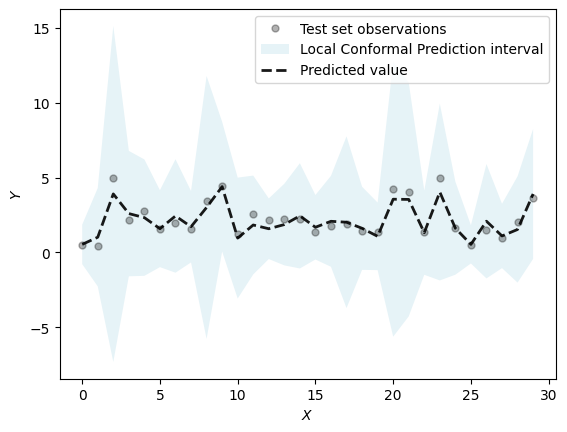


 ----- Running: Diabetes ----- 


 ---------- Initialize the unified regr (example with XGBoost)
Time taken: 0.04557180404663086 seconds
Coverage rate: 0.9438


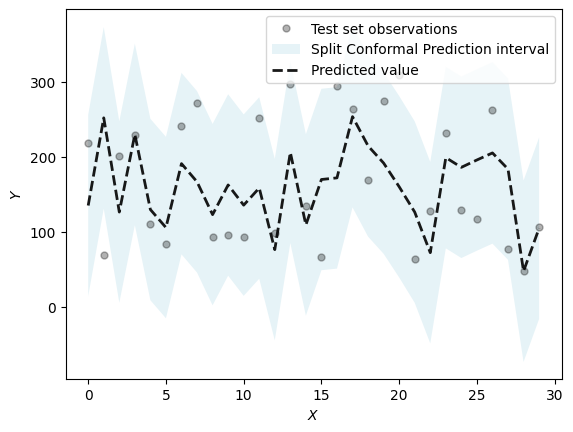


 ---------- Initialize the unified regr (example with LightGBM)
Time taken: 0.17367887496948242 seconds
Coverage rate: 1.0000


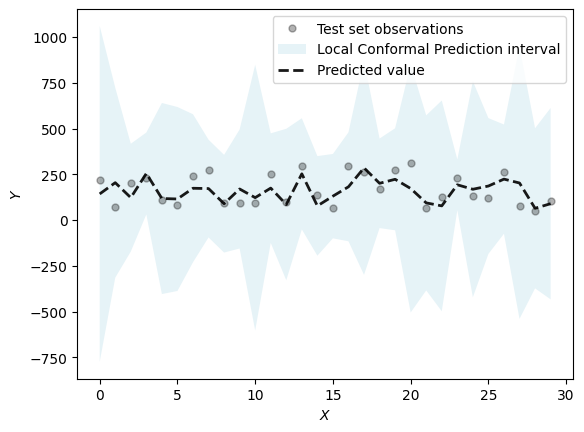

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import unifiedbooster as ub
import warnings
from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.model_selection import train_test_split
from time import time



load_datasets = [fetch_california_housing(), load_diabetes()]
dataset_names = ["California Housing", "Diabetes"]

warnings.filterwarnings('ignore')

split_color = 'green'
split_color2 = 'orange'
local_color = 'gray'

def plot_func(x,
              y,
              y_u=None,
              y_l=None,
              pred=None,
              shade_color="lightblue",
              method_name="",
              title=""):

    fig = plt.figure()

    plt.plot(x, y, 'k.', alpha=.3, markersize=10,
             fillstyle='full', label=u'Test set observations')

    if (y_u is not None) and (y_l is not None):
        plt.fill(np.concatenate([x, x[::-1]]),
                 np.concatenate([y_u, y_l[::-1]]),
                 alpha=.3, fc=shade_color, ec='None',
                 label = method_name + ' Prediction interval')

    if pred is not None:
        plt.plot(x, pred, 'k--', lw=2, alpha=0.9,
                 label=u'Predicted value')

    #plt.ylim([-2.5, 7])
    plt.xlabel('$X$')
    plt.ylabel('$Y$')
    plt.legend(loc='upper right')
    plt.title(title)

    plt.show()

for i, dataset in enumerate(load_datasets):

    print(f"\n ----- Running: {dataset_names[i]} ----- \n")
    X, y = dataset.data, dataset.target

    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Initialize the unified regr (example with XGBoost)
    print("\n ---------- Initialize the unified regr (example with XGBoost)")
    regr1 = ub.GBDTRegressor(model_type="xgboost",
                            level=95,
                            pi_method="splitconformal")

    # Fit the model
    start = time()
    regr1.fit(X_train, y_train)
    print(f"Time taken: {time() - start} seconds")
    # Predict with the model
    y_pred1 = regr1.predict(X_test)
    # Coverage error
    coverage_error = (y_test >= y_pred1.lower) & (y_test <= y_pred1.upper)
    print(f"Coverage rate: {coverage_error.mean():.4f}")
    #x,
    #y,
    #y_u=None,
    #y_l=None,
    #pred=None,
    plot_func(range(len(y_test))[0:30], y_test[0:30],
              y_pred1.upper[0:30], y_pred1.lower[0:30],
              y_pred1.mean[0:30], method_name="Split Conformal")

    print("\n ---------- Initialize the unified regr (example with LightGBM)")
    regr2 = ub.GBDTRegressor(model_type="lightgbm",
                            level=95,
                            pi_method="localconformal")
    # Fit the model
    start = time()
    regr2.fit(X_train, y_train)
    print(f"Time taken: {time() - start} seconds")
    # Predict with the model
    y_pred2 = regr2.predict(X_test)
    # Coverage error
    coverage_error = (y_test >= y_pred2.lower) & (y_test <= y_pred2.upper)
    print(f"Coverage rate: {coverage_error.mean():.4f}")
    #x,
    #y,
    #y_u=None,
    #y_l=None,
    #pred=None,
    plot_func(range(len(y_test))[0:30], y_test[0:30],
              y_pred2.upper[0:30], y_pred2.lower[0:30],
              y_pred2.mean[0:30], method_name="Local Conformal")

In [9]:
import numpy as np
import os
import unifiedbooster as ub
from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from time import time


load_datasets = [load_iris(), load_breast_cancer(), load_wine()]
dataset_names = ["Iris", "Breast Cancer", "Wine"]

for i, dataset in enumerate(load_datasets):

    print(f"\n ----- Running: {dataset_names[i]} ----- \n")
    X, y = dataset.data, dataset.target

    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Initialize the unified clf (example with XGBoost)
    print("\n ---------- Initialize the unified clf (example with XGBoost)")
    clf1 = ub.GBDTClassifier(model_type="xgboost",
                            level=95,
                            pi_method="tcp")

    # Fit the model
    start = time()
    clf1.fit(X_train, y_train)
    print(f"Time taken: {time() - start} seconds")
    # Predict with the model
    y_pred1 = clf1.predict(X_test)
    print(y_test)
    print(y_pred1.argmax(axis=1))
    # Calculate accuracy
    accuracy = (y_test == y_pred1.argmax(axis=1)).mean()
    print(f"\nAccuracy: {accuracy:.4f}")

    print("\n ---------- Initialize the unified clf (example with LightGBM)")
    clf2 = ub.GBDTClassifier(model_type="lightgbm",
                            level=95,
                            pi_method="icp")
    # Fit the model
    start = time()
    clf2.fit(X_train, y_train)
    print(f"Time taken: {time() - start} seconds")
    # Predict with the model
    y_pred2 = clf2.predict(X_test)
    print(y_pred2)

    # Calculate accuracy
    print(y_test)
    print(y_pred2.argmax(axis=1))
    accuracy = (y_test == y_pred2.argmax(axis=1)).mean()
    print(f"\nAccuracy: {accuracy:.4f}")


 ----- Running: Iris ----- 


 ---------- Initialize the unified clf (example with XGBoost)
Time taken: 8.749961853027344e-05 seconds
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy: 1.0000

 ---------- Initialize the unified clf (example with LightGBM)
Time taken: 0.019047260284423828 seconds
[[False  True  True]
 [ True False False]
 [False False  True]
 [False  True False]
 [False  True  True]
 [ True False False]
 [False  True False]
 [False False  True]
 [False  True False]
 [False  True False]
 [False False  True]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [False  True  True]
 [False False  True]
 [False  True False]
 [False  True False]
 [False False  True]
 [ True False False]
 [False False  True]
 [ True False False]
 [False False  True]
 [False False  True]
 [False False  True]
 [False False  True]
 [False False  True]
 [ True False False]
 [ True F

In [10]:
import os
import unifiedbooster as ub
from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import accuracy_score
from time import time


dataset = load_breast_cancer()
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n Example 1 -----")

res1 = ub.cross_val_optim(
    X_train,
    y_train,
    X_test=None,
    y_test=None,
    model_type="lightgbm",
    type_fit="classification",
    scoring="accuracy",
    n_estimators=100,
    surrogate_obj=None,
    cv=5,
    n_jobs=None,
    n_init=10,
    n_iter=190,
    abs_tol=1e-3,
    verbose=2,
    seed=123,
)
print(res1)

print("\n Example 2 -----")

res2 = ub.cross_val_optim(
    X_train,
    y_train,
    X_test=X_test,
    y_test=y_test,
    model_type="lightgbm",
    type_fit="classification",
    scoring="accuracy",
    n_estimators=100,
    surrogate_obj=None,
    cv=5,
    n_jobs=None,
    n_init=10,
    n_iter=190,
    abs_tol=1e-3,
    verbose=2,
    seed=123,
)
print(res2)

print("\n Example 3 -----")

res3 = ub.cross_val_optim(
    X_train,
    y_train,
    X_test=X_test,
    y_test=y_test,
    model_type="lightgbm",
    type_fit="classification",
    scoring="accuracy",
    n_estimators=100,
    surrogate_obj=KernelRidge(),
    cv=5,
    n_jobs=None,
    n_init=10,
    n_iter=190,
    abs_tol=1e-3,
    verbose=2,
    seed=123,
)
print(res3)

print("\n Example 4 -----")

res2 = ub.cross_val_optim(
    X_train,
    y_train,
    X_test=X_test,
    y_test=y_test,
    model_type="lightgbm",
    type_fit="classification",
    scoring="accuracy",
    surrogate_obj=None,
    cv=5,
    n_jobs=None,
    n_init=10,
    n_iter=190,
    abs_tol=1e-3,
    verbose=2,
    seed=123,
)
print(res2)

print("\n Example 5 -----")

res3 = ub.cross_val_optim(
    X_train,
    y_train,
    X_test=X_test,
    y_test=y_test,
    model_type="lightgbm",
    type_fit="classification",
    scoring="accuracy",
    surrogate_obj=KernelRidge(),
    cv=5,
    n_jobs=None,
    n_init=10,
    n_iter=190,
    abs_tol=1e-3,
    verbose=2,
    seed=123,
)
print(res3)



 Example 1 -----

 Creating initial design... 


 ...Done. 


 Optimization loop... 

iteration 1 -----
current minimum:  [-0.75   14.125   0.5625  0.8125]
current minimum score:  -0.9670329670329669
next parameter: [-0.0276947   3.88928986  0.97082138  0.62102127]
score for next parameter: -0.9670329670329669 

iteration 2 -----
current minimum:  [-0.75   14.125   0.5625  0.8125]
current minimum score:  -0.9670329670329669
next parameter: [-0.11251831 12.71989441  0.98590851  0.56124115]
score for next parameter: -0.9670329670329669 

iteration 3 -----
current minimum:  [-0.75   14.125   0.5625  0.8125]
current minimum score:  -0.9670329670329669
next parameter: [-0.76318359  3.90405273  0.51574707  0.96691895]
score for next parameter: -0.9626373626373625 

iteration 4 -----
current minimum:  [-0.75   14.125   0.5625  0.8125]
current minimum score:  -0.9670329670329669
next parameter: [-0.84503174 13.64022827  0.97843933  0.55198669]
score for next parameter: -0.9604395604395604 

i

In [11]:
import os
import unifiedbooster as ub
from sklearn.datasets import load_iris, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import accuracy_score
from time import time



dataset = load_breast_cancer()
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# start = time()
# res3 = ub.lazy_cross_val_optim(
#     X_train,
#     y_train,
#     X_test=X_test,
#     y_test=y_test,
#     model_type="lightgbm",
#     type_fit="classification",
#     scoring="accuracy",
#     n_estimators=100,
#     cv=5,
#     n_jobs=None,
#     n_init=10,
#     n_iter=190,
#     abs_tol=1e-3,
#     seed=123,
#     customize=True
# )
# print(f"Elapsed: {time()-start}")

start = time()
res4 = ub.lazy_cross_val_optim(
    X_train,
    y_train,
    X_test=X_test,
    y_test=y_test,
    model_type="lightgbm",
    type_fit="classification",
    scoring="accuracy",
    n_estimators=100,
    cv=5,
    n_jobs=None,
    n_init=10,
    n_iter=190,
    abs_tol=1e-3,
    seed=123,
    customize=False
)
print(f"Elapsed: {time()-start}")
#print(res3)
print(res4)


start = time()
res4 = ub.lazy_cross_val_optim(
    X_train,
    y_train,
    X_test=X_test,
    y_test=y_test,
    model_type="lightgbm",
    type_fit="classification",
    scoring="accuracy",
    cv=5,
    n_jobs=None,
    n_init=10,
    n_iter=190,
    abs_tol=1e-3,
    seed=123,
    customize=False
)
print(f"Elapsed: {time()-start}")
#print(res3)
print(res4)



 surrogate: AdaBoostRegressor

 Creating initial design... 


 ...Done. 


 Optimization loop... 

190/190 [██████████████████████████████] - 30s 156ms/step

 result: result(best_params={'learning_rate': np.float64(0.9395078012230446), 'max_depth': 12, 'rowsample': np.float64(0.83123779296875), 'colsample': np.float64(0.82318115234375), 'model_type': 'lightgbm', 'n_estimators': 100}, best_score=np.float64(-0.9714285714285713), test_accuracy=0.9649122807017544)

 surrogate: BaggingRegressor

 Creating initial design... 


 ...Done. 


 Optimization loop... 

190/190 [██████████████████████████████] - 14s 75ms/step

 result: result(best_params={'learning_rate': np.float64(0.9785208149931084), 'max_depth': 1, 'rowsample': np.float64(0.9417037963867188), 'colsample': np.float64(0.5160903930664062), 'model_type': 'lightgbm', 'n_estimators': 100}, best_score=np.float64(-0.9736263736263735), test_accuracy=0.9736842105263158)

 surrogate: BayesianRidge

 Creating initial design... 


 ...Done

In [12]:
import os
import unifiedbooster as ub
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error


# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the unified regr (example with XGBoost)
regr1 = ub.GBDTRegressor(model_type="xgboost")
# regr2 = ub.GBDTRegressor(model_type='catboost')
regr3 = ub.GBDTRegressor(model_type="lightgbm")
regr4 = ub.GBDTRegressor(model_type="gradientboosting", colsample=0.9)

# Fit the model
regr1.fit(X_train, y_train)
# regr2.fit(X_train, y_train)
regr3.fit(X_train, y_train)
regr4.fit(X_train, y_train)

# Predict on the test set
y_pred1 = regr1.predict(X_test)
# y_pred2 = regr2.predict(X_test)
y_pred3 = regr3.predict(X_test)
y_pred4 = regr4.predict(X_test)

# Evaluate the model
mse1 = mean_squared_error(y_test, y_pred1)
# mse2 = mean_squared_error(y_test, y_pred2)
mse3 = mean_squared_error(y_test, y_pred3)
mse4 = mean_squared_error(y_test, y_pred4)
print(f"Regression Mean Squared Error xgboost: {mse1:.2f}")
# print(f"Regression Mean Squared Error catboost: {mse2:.2f}")
print(f"Regression Mean Squared Error lightgbm: {mse3:.2f}")
print(f"Regression Mean Squared Error gradientboosting: {mse4:.2f}")
print(f"CV xgboost: {cross_val_score(regr1, X_train, y_train)}")
print(f"CV lightgbm: {cross_val_score(regr3, X_train, y_train)}")
print(f"CV gradientboosting: {cross_val_score(regr4, X_train, y_train)}")


Regression Mean Squared Error xgboost: 0.30
Regression Mean Squared Error lightgbm: 0.29
Regression Mean Squared Error gradientboosting: 0.29
CV xgboost: [0.78816361 0.78921416 0.78892925 0.78295958 0.78155438]
CV lightgbm: [0.79038324 0.79178274 0.79325961 0.78420756 0.78289292]
CV gradientboosting: [0.79200803 0.78864833 0.79150303 0.78529893 0.78141304]
